In [18]:
import sys 
from pathlib import Path
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor, Pool

sys.path.append(str(Path.cwd().parent))

In [2]:
import pandas as pd 
from sqlalchemy import create_engine
from backend.settings import settings

engine = create_engine(settings.DATABASE_URL)

table_name = settings.VIEW_OR_TABLE     # "fact_listings"
schema_name = settings.SCHEMA           # default "realestate"

df = pd.read_sql_table(table_name, con=engine, schema=schema_name)



In [3]:
df = pd.read_sql_query(
    """
    SELECT *
    FROM realestate.fact_listings
    """,
    con=engine,
)

In [4]:
df.head()

,listing_id,snapshot_date,city,type,square_m,rooms,floor,floor_count,build_year,latitude,...,ownership,building_material,condition,has_parking_space,has_balcony,has_elevator,has_security,has_storage_room,price,geom
0,c26796554585aaa084f00bd8a9f00690,2024-01-01,poznan,None,43.00,2,NaN,NaN,1964.0,52.416547,...,condominium,None,None,False,False,None,False,False,449000.0,0101000020E6100000F33405D781E23040C49E2C6B5135...
1,2535aa4258f53f4c5495a54d640c802a,2024-01-01,poznan,None,37.54,2,NaN,4.0,2023.0,52.404513,...,condominium,None,None,False,False,None,False,False,619410.0,0101000020E6100000E02582829CEF3040F3E8A111C733...
2,23a3d6f183684e6c12567095df374232,2024-01-01,poznan,blockOfFlats,33.10,1,3.0,4.0,1969.0,52.417090,...,condominium,brick,None,False,False,False,True,True,390000.0,0101000020E61000007D3F355EBAE130408CBE82346335...
3,327ed4902457986b2bc1a013ea4e8844,2024-01-01,poznan,tenement,49.70,2,3.0,4.0,NaN,52.398710,...,condominium,brick,None,False,True,False,False,False,399000.0,0101000020E610000080D4264EEEE73040494BE5ED0833...
4,9ab80e2836da53e5e28caa2ce3c92a83,2024-01-01,poznan,tenement,76.94,3,3.0,4.0,1900.0,52.398806,...,condominium,brick,None,False,False,None,False,False,749000.0,0101000020E61000007965EE8C7CE730400C9AF1110C33...


In [5]:
df

,listing_id,snapshot_date,city,type,square_m,rooms,floor,floor_count,build_year,latitude,...,ownership,building_material,condition,has_parking_space,has_balcony,has_elevator,has_security,has_storage_room,price,geom
0,c26796554585aaa084f00bd8a9f00690,2024-01-01,poznan,None,43.00,2,NaN,NaN,1964.0,52.416547,...,condominium,None,None,False,False,None,False,False,449000.0,0101000020E6100000F33405D781E23040C49E2C6B5135...
1,2535aa4258f53f4c5495a54d640c802a,2024-01-01,poznan,None,37.54,2,NaN,4.0,2023.0,52.404513,...,condominium,None,None,False,False,None,False,False,619410.0,0101000020E6100000E02582829CEF3040F3E8A111C733...
2,23a3d6f183684e6c12567095df374232,2024-01-01,poznan,blockOfFlats,33.10,1,3.0,4.0,1969.0,52.417090,...,condominium,brick,None,False,False,False,True,True,390000.0,0101000020E61000007D3F355EBAE130408CBE82346335...
3,327ed4902457986b2bc1a013ea4e8844,2024-01-01,poznan,tenement,49.70,2,3.0,4.0,NaN,52.398710,...,condominium,brick,None,False,True,False,False,False,399000.0,0101000020E610000080D4264EEEE73040494BE5ED0833...
4,9ab80e2836da53e5e28caa2ce3c92a83,2024-01-01,poznan,tenement,76.94,3,3.0,4.0,1900.0,52.398806,...,condominium,brick,None,False,False,None,False,False,749000.0,0101000020E61000007965EE8C7CE730400C9AF1110C33...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266410,6ad7afd5b303a5421c2f79edf9f419f2,2024-01-01,poznan,apartmentBuilding,50.00,2,3.0,5.0,2015.0,52.409035,...,condominium,brick,premium,False,True,True,False,False,820000.0,0101000020E6100000C5168A8DDCF0304019366F415B34...
266411,5014ec66b43358450437030e19e17d4e,2024-01-01,poznan,blockOfFlats,59.40,2,1.0,3.0,2003.0,52.464910,...,condominium,brick,premium,True,True,False,False,True,640000.0,0101000020E61000000FD6FF39CCEF3040ACCABE2B823B...
266412,db2354b93053b883cd0b8a0f1bf6cc2c,2024-01-01,poznan,None,49.00,2,4.0,5.0,2024.0,52.406000,...,condominium,None,None,False,False,True,False,False,491000.0,0101000020E6100000B29DEFA7C6FB30408716D9CEF733...
266413,1e542fa3372c02bb88e430cc2b280cf3,2024-01-01,poznan,tenement,58.80,2,NaN,4.0,1920.0,52.413818,...,condominium,brick,premium,True,False,None,False,False,823200.0,0101000020E61000002A24F48EAEE9304057C04EFBF734...


### Predict the price for properties

#### Manifulation column

In [6]:
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'], errors='coerce')
df = df.dropna(subset=['snapshot_date'])
df = df.sort_values(['listing_id', 'snapshot_date'])

In [8]:
df['prev_price']       = df.groupby('listing_id')['price'].shift(1)
df['price_change']     = df['price'] - df['prev_price']
df['price_change_pct'] = df['price_change'] / df['prev_price']
df['days_since_prev']  = df.groupby('listing_id')['snapshot_date'].diff().dt.days

- Exclude lowest and highest price to avoid unacceptable point

In [7]:
df = df[df['price'].between(10_000, 5_000_000)]

- target_price means next month price 

In [10]:
df['next_price']   = df.groupby('listing_id')['price'].shift(-1)
df['target_price'] = df['next_price']

In [11]:
df = df.dropna(subset=['target_price'])

In [12]:
cat_cols = [c for c in ['city','type','ownership','building_material','condition'] if c in df.columns]
has_cols = [c for c in df.columns if c.startswith('has_')]
num_candidates = [
    'square_m','rooms','floor','floor_count','build_year','latitude','longitude',
    'centre_distance','poi_count','school_distance','clinic_distance','post_office_distance',
    'kindergarten_distance','restaurant_distance','college_distance','pharmacy_distance',
    'price','price_change','price_change_pct','days_since_prev'
]
num_cols = [c for c in num_candidates if c in df.columns]
feature_cols = cat_cols + has_cols + num_cols
target_col = 'target_price'

In [13]:
df_model = df[feature_cols + [target_col, 'snapshot_date','listing_id']].copy()

for c in num_cols + has_cols:
    if c in df_model.columns:
        df_model[c] = pd.to_numeric(df_model[c], errors='coerce')

for c in num_cols:
    med = df_model[c].median()
    df_model[c] = df_model[c].fillna(med).astype('float32')

for c in has_cols:
    df_model[c] = df_model[c].fillna(0).astype('int8')

for c in cat_cols:
    df_model[c] = df_model[c].astype('string').fillna('NA')


In [14]:
X_all = df_model[feature_cols].copy()
y_all = np.log1p(df_model[target_col].astype(float))

- Time based split

In [15]:
split_date = df_model['snapshot_date'].quantile(0.8)
train_mask = df_model['snapshot_date'] <= split_date
valid_mask = ~train_mask

X_train, X_valid = X_all[train_mask], X_all[valid_mask]
y_train, y_valid = y_all[train_mask], y_all[valid_mask]


In [19]:
# m_tr = y_train.notna() & np.isfinite(y_train)
# m_va = y_valid.notna() & np.isfinite(y_valid)
# X_train, y_train = X_train.loc[m_tr], y_train.loc[m_tr]
# X_valid, y_valid = X_valid.loc[m_va], y_valid.loc[m_va]

cat_idx = [X_all.columns.get_loc(c) for c in cat_cols if c in X_all.columns]
train_pool = Pool(X_train, label=y_train, cat_features=cat_idx)
valid_pool = Pool(X_valid, label=y_valid, cat_features=cat_idx)

- Train model

In [20]:
need_train = True
try:
    need_train = not (('model' in globals()) and hasattr(model, 'tree_count_') and model.tree_count_ is not None)
except:
    need_train = True

if need_train:
    model = CatBoostRegressor(
        loss_function='RMSE',
        depth=8,
        learning_rate=0.05,
        n_estimators=4000,
        random_seed=42,
        eval_metric='RMSE',
        od_type='Iter',
        od_wait=200,
        verbose=200
    )
    model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

0:	learn: 0.6455500	test: 0.6288018	best: 0.6288018 (0)	total: 150ms	remaining: 10m
200:	learn: 0.0281991	test: 0.0266945	best: 0.0266945 (200)	total: 9.13s	remaining: 2m 52s
400:	learn: 0.0270917	test: 0.0261528	best: 0.0261528 (399)	total: 19.3s	remaining: 2m 53s
600:	learn: 0.0263520	test: 0.0258714	best: 0.0258714 (600)	total: 29s	remaining: 2m 44s
800:	learn: 0.0257584	test: 0.0257255	best: 0.0257255 (800)	total: 39.3s	remaining: 2m 37s
1000:	learn: 0.0252690	test: 0.0256095	best: 0.0256094 (998)	total: 51.5s	remaining: 2m 34s
1200:	learn: 0.0248369	test: 0.0255566	best: 0.0255566 (1200)	total: 1m 2s	remaining: 2m 25s
1400:	learn: 0.0244775	test: 0.0255181	best: 0.0255167 (1399)	total: 1m 13s	remaining: 2m 15s
1600:	learn: 0.0241371	test: 0.0254939	best: 0.0254931 (1595)	total: 1m 24s	remaining: 2m 7s
1800:	learn: 0.0237949	test: 0.0254580	best: 0.0254570 (1792)	total: 1m 36s	remaining: 1m 57s
2000:	learn: 0.0234969	test: 0.0254499	best: 0.0254472 (1967)	total: 1m 48s	remaining: 1

- Validataion checks on the model

In [22]:
pred_log = model.predict(valid_pool)
y_real = np.expm1(y_valid.to_numpy())
p_real = np.expm1(pred_log)
mae  = mean_absolute_error(y_real, p_real)
rmse = np.sqrt(mean_squared_error(y_real, p_real))
print(f"Validation check — MAE: {mae:,.0f} PLN | RMSE: {rmse:,.0f} PLN")

Validation check — MAE: 10,546 PLN | RMSE: 26,311 PLN


- Build latest snapshot per listing and predict next price

In [23]:
df_latest = (
    df.sort_values(['listing_id','snapshot_date'])
      .groupby('listing_id', as_index=False)
      .tail(1)
      .reset_index(drop=True)
)

latest_X = df_latest.reindex(columns=feature_cols).copy()

In [24]:
for c in num_cols:
    latest_X[c] = pd.to_numeric(latest_X[c], errors='coerce')
    latest_X[c] = latest_X[c].fillna(df_model[c].median()).astype('float32')

for c in has_cols:
    latest_X[c] = latest_X[c].fillna(0).astype('int8')

for c in cat_cols:
    latest_X[c] = latest_X[c].astype('string').fillna('NA')

latest_pool = Pool(latest_X, cat_features=cat_idx)
pred_next_log = model.predict(latest_pool)
df_latest['predicted_next_price'] = np.expm1(pred_next_log)

In [25]:
df_latest['predicted_change_pln'] = df_latest['predicted_next_price'] - df_latest['price']
df_latest['predicted_change_pct'] = 100.0 * df_latest['predicted_change_pln'] / np.clip(df_latest['price'], 1, None)


In [26]:
cols_to_show = ['listing_id','snapshot_date','city','type','price','predicted_next_price','predicted_change_pln','predicted_change_pct']
cols_to_show = [c for c in cols_to_show if c in df_latest.columns]
df_latest_pred = df_latest[cols_to_show].sort_values('predicted_change_pct', ascending=False)

print("\nSample predictions:")
print(df_latest_pred.head(10).to_string(index=False))


Sample predictions:
                      listing_id snapshot_date      city              type    price  predicted_next_price  predicted_change_pln  predicted_change_pct
1435e296e9fbb519df98302934abfe4b    2023-08-01    krakow              None 299000.0         472483.407638         173483.407638             58.021207
bd08a3f03f9501e4f67ba2802591c5aa    2024-02-01    poznan apartmentBuilding 358000.0         511150.001938         153150.001938             42.779330
7cb93c7804dadde276b4359bf0f06957    2023-08-01 bydgoszcz      blockOfFlats 267000.0         373630.761605         106630.761605             39.936615
a6fc58b2671d4f864cb7df6bc0140227    2024-03-01      lodz              None 240000.0         307849.157704          67849.157704             28.270482
0d21af75c59601a7fccdf1ec3bc585db    2023-11-01  warszawa      blockOfFlats 439000.0         552252.796761         113252.796761             25.797904
31171e780aafea873aada04c636ee6fe    2024-02-01    poznan apartmentBuilding 3610

In [29]:
df_price_down = df_latest_pred[df_latest_pred['predicted_change_pln'] < 0].copy()
df_price_down = df_price_down.sort_values('predicted_change_pln')
df_price_down

,listing_id,snapshot_date,city,type,price,predicted_next_price,predicted_change_pln,predicted_change_pct
6321,232f3fbc2422f533f5db05cbdbb73b9c,2024-03-01,warszawa,None,1490000.0,9.977310e+05,-492269.037271,-33.038190
8120,2d0b01ec846416cd9ee4f02e83d8ea0b,2024-03-01,warszawa,apartmentBuilding,2258870.0,2.001267e+06,-257603.278188,-11.404077
7494,2979515db41a69636d39b3278ceafbfc,2024-02-01,krakow,None,750000.0,5.083920e+05,-241607.964070,-32.214395
34464,c067519d53dfc79b6f53f673ddd8661a,2024-03-01,warszawa,blockOfFlats,2258870.0,2.022215e+06,-236655.185045,-10.476707
37173,cff5236190759a59d0731171843d1335,2023-12-01,warszawa,blockOfFlats,3200000.0,2.966370e+06,-233630.256122,-7.300946
...,...,...,...,...,...,...,...,...
18500,6782cc07790350c49fbb2238f99cb21e,2023-09-01,poznan,blockOfFlats,415000.0,4.149978e+05,-2.191664,-0.000528
3754,14e0b471181eccf87fac96a4b9efda8a,2024-05-01,warszawa,apartmentBuilding,10800.0,1.079816e+04,-1.838773,-0.017026
32517,b54253922cd4d284295971cc5813ddbc,2023-12-01,warszawa,blockOfFlats,590000.0,5.899985e+05,-1.538006,-0.000261
35306,c532cd71943d97015d92d541b5ca895c,2023-10-01,lodz,blockOfFlats,240000.0,2.399985e+05,-1.489084,-0.000620


In [31]:
df

,listing_id,snapshot_date,city,type,square_m,rooms,floor,floor_count,build_year,latitude,...,has_security,has_storage_room,price,geom,prev_price,price_change,price_change_pct,days_since_prev,next_price,target_price
59166,0001bc480f7a6cda692806924c76fba5,2024-04-01,warszawa,blockOfFlats,85.00,3,1.0,3.0,2009.0,52.233800,...,True,True,1275000.0,0101000020E6100000C58F31772D21354004E78C28ED1D...,NaN,NaN,NaN,NaN,1175000.0,1175000.0
81070,0001bc480f7a6cda692806924c76fba5,2024-05-01,warszawa,blockOfFlats,85.17,3,1.0,3.0,2009.0,52.234000,...,True,True,1175000.0,0101000020E6100000A8C64B3789213540CBA145B6F31D...,1275000.0,-100000.0,-0.078431,30.0,1175000.0,1175000.0
80623,00025289e006d3788dab1a6cea12d790,2024-05-01,warszawa,blockOfFlats,38.50,2,1.0,10.0,1973.0,52.205880,...,False,True,689900.0,0101000020E61000000B462575020A354043739D465A1A...,NaN,NaN,NaN,NaN,689900.0,689900.0
263944,0008f66ddcf09af1284cc3a271e98144,2024-01-01,krakow,None,39.62,2,1.0,2.0,NaN,50.094410,...,False,True,630000.0,0101000020E6100000A0FD4811190E34402B357BA0150C...,NaN,NaN,NaN,NaN,630000.0,630000.0
18246,000967d7ab16f577f7c16cce90215669,2024-02-01,wroclaw,apartmentBuilding,53.00,2,2.0,4.0,2010.0,51.120355,...,False,False,695000.0,0101000020E6100000C687D9CBB6ED30407E74EACA678F...,NaN,NaN,NaN,NaN,695000.0,695000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6256,ffff369f1fb57bff8d9180282051be1a,2024-01-01,czestochowa,None,67.00,2,1.0,2.0,NaN,50.777860,...,False,False,390000.0,0101000020E6100000CFA3E2FF8E28334057AFC7E99063...,390000.0,0.0,0.000000,31.0,390000.0,390000.0
22138,ffff369f1fb57bff8d9180282051be1a,2024-02-01,czestochowa,None,67.00,2,1.0,2.0,NaN,50.777860,...,False,False,390000.0,0101000020E6100000CFA3E2FF8E28334057AFC7E99063...,390000.0,0.0,0.000000,31.0,390000.0,390000.0
39092,ffff369f1fb57bff8d9180282051be1a,2024-03-01,czestochowa,None,67.00,2,1.0,2.0,NaN,50.777860,...,False,False,390000.0,0101000020E6100000CFA3E2FF8E28334057AFC7E99063...,390000.0,0.0,0.000000,29.0,390000.0,390000.0
57492,ffff369f1fb57bff8d9180282051be1a,2024-04-01,czestochowa,None,67.00,2,1.0,2.0,NaN,50.777860,...,False,False,390000.0,0101000020E6100000CFA3E2FF8E28334057AFC7E99063...,390000.0,0.0,0.000000,31.0,390000.0,390000.0


#### Compare price history and predicted one

In [39]:
df_hist = df.copy()
df_hist['snapshot_date'] = pd.to_datetime(df_hist['snapshot_date'])
df_hist = df_hist.dropna(subset=['snapshot_date'])
df_hist['is_predicted'] = False  # <- ensure boolean


In [40]:
# relevan column 
cols_hist = ['listing_id', 'snapshot_date', 'price']
if 'city' in df_hist.columns:
    cols_hist.append('city')
if 'type' in df_hist.columns:
    cols_hist.append('type')

df_hist = df_hist[cols_hist]

In [41]:
# add df_future
df_future = df_latest_pred[['listing_id', 'predicted_next_price']].copy()
df_future['snapshot_date'] = (
    df_latest_pred['snapshot_date'] + pd.Timedelta(days=30)
) 
df_future['price'] = df_future['predicted_next_price']
df_future['is_predicted'] = True

In [37]:
df_future

,listing_id,predicted_next_price,snapshot_date,price,is_predicted
3626,1435e296e9fbb519df98302934abfe4b,472483.407638,2023-08-31,472483.407638,True
33852,bd08a3f03f9501e4f67ba2802591c5aa,511150.001938,2024-03-02,511150.001938,True
22270,7cb93c7804dadde276b4359bf0f06957,373630.761605,2023-08-31,373630.761605,True
29977,a6fc58b2671d4f864cb7df6bc0140227,307849.157704,2024-03-31,307849.157704,True
2369,0d21af75c59601a7fccdf1ec3bc585db,552252.796761,2023-12-01,552252.796761,True
...,...,...,...,...,...
25195,8cf4e760e16f7f8d9a4b3b33e94abc65,286301.193910,2023-10-31,286301.193910,True
37625,d2673da2fc92f5b05f2bde58360e7f38,438406.896385,2023-10-31,438406.896385,True
7494,2979515db41a69636d39b3278ceafbfc,508392.035930,2024-03-02,508392.035930,True
6321,232f3fbc2422f533f5db05cbdbb73b9c,997730.962729,2024-03-31,997730.962729,True


In [34]:
df_all = pd.concat([df_hist, df_future], ignore_index=True)
df_all = df_all.sort_values(['listing_id', 'snapshot_date'])


In [42]:
df_all['is_predicted'] = df_all['is_predicted'].fillna(False).astype(bool)

/var/folders/z9/q3kww6xn0_s3n8lbzf8cswhc0000gn/T/ipykernel_4987/1546639406.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all['is_predicted'] = df_all['is_predicted'].fillna(False).astype(bool)


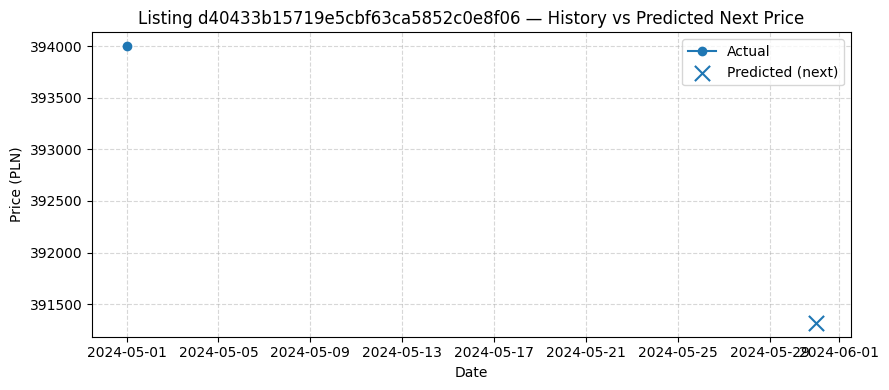

In [ ]:
# to check only one sample 
import matplotlib.pyplot as plt

# Pick one example property
sample_id = df_future['listing_id'].sample(1, random_state=42).values[0]
sample = df_all[df_all['listing_id'] == sample_id]

actual = sample.loc[sample['is_predicted'] == False]
pred   = sample.loc[sample['is_predicted'] == True]

plt.figure(figsize=(9,4))
plt.plot(actual['snapshot_date'], actual['price'], 'o-', label='Actual')
if not pred.empty:
    plt.scatter(pred['snapshot_date'], pred['price'], marker='x', s=120, label='Predicted (next)')
plt.title(f'Listing {sample_id} — History vs Predicted Next Price')
plt.xlabel('Date'); plt.ylabel('Price (PLN)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
# plt.figure(figsize=(8, 4))
# plt.plot(sample['snapshot_date'], sample['price'],
#          'o-', label='Actual Price', alpha=0.7)

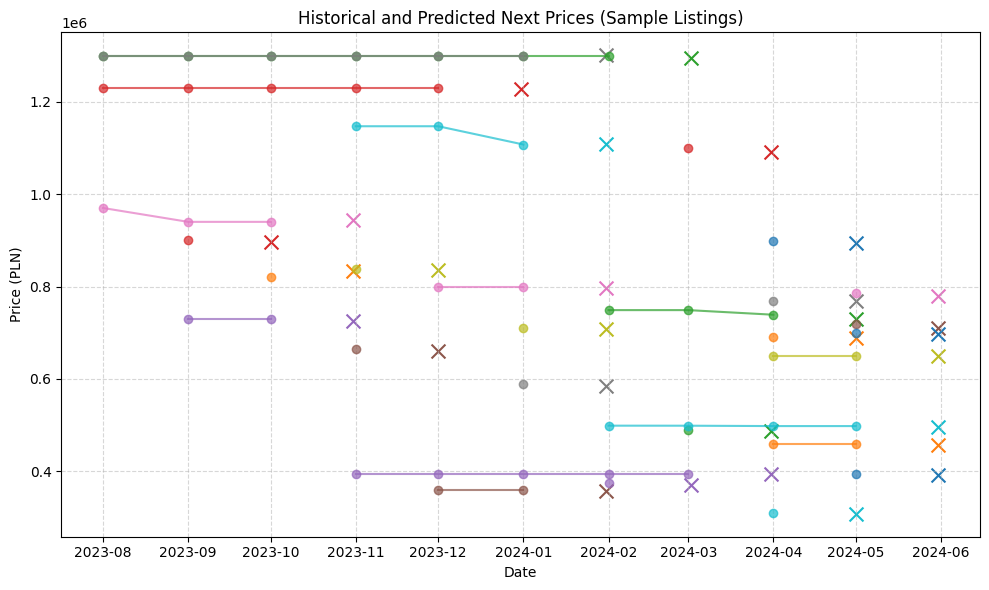

In [ ]:
# pick N random listings that have predictions
sample_ids = df_future['listing_id'].dropna().sample(30, random_state=42).values

plt.figure(figsize=(10, 6))

for lid in sample_ids:
    s = df_all[df_all['listing_id'] == lid]
    actual = s[s['is_predicted'] == False]
    pred = s[s['is_predicted'] == True]

    # plot historical prices
    plt.plot(actual['snapshot_date'], actual['price'], 'o-', alpha=0.7, label=f'{lid} Actual')
    # plot predicted next price
    if not pred.empty:
        plt.scatter(pred['snapshot_date'], pred['price'], marker='x', s=100, label=f'{lid} Predicted')

plt.title('Historical and Predicted Next Prices (Sample Listings)')
plt.xlabel('Date')
plt.ylabel('Price (PLN)')
# plt.legend(fontsize='small', ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Evaluation

- Evaluate global performance
- mae : average absolute error , lower is better typical diff between real and predicted
- rmse : big erros 
- mape : Mean % error , average percent deviation
- smape : symmetric mape , comparison high and low price

- Those metrics are all calculated over every prediction in validation set.
- Each prediction corresponds to one snapshot of one listing

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


pred_valid_log = model.predict(valid_pool)
# log to PLN
y_real = np.expm1(y_valid.to_numpy())        # true next prices
p_real = np.expm1(pred_valid_log)            # predicted next prices

mae  = mean_absolute_error(y_real, p_real)
rmse = np.sqrt(mean_squared_error(y_real, p_real))
mape = np.mean(np.abs((y_real - p_real) / np.clip(y_real, 1, None))) * 100
smape = 100 * np.mean(2 * np.abs(p_real - y_real) /
                      (np.abs(p_real) + np.abs(y_real) + 1e-9))

print(f"FUTURE SNAPSHOT — "
      f"MAE: {mae:,.0f} PLN | "
      f"RMSE: {rmse:,.0f} PLN | "
      f"MAPE: {mape:.2f}% | " 
      f"sMAPE: {smape:.2f}%")


FUTURE SNAPSHOT — MAE: 10,546 PLN | RMSE: 26,311 PLN | MAPE: 1.27% | sMAPE: 1.25%


“Across all listings in the validation dataset,
the model’s predicted next price is, on average, about 10 546 PLN different from the true next price (≈ 1.3 % error).”

- How aacurate the model for each property

In [52]:
df_valid_eval = pd.DataFrame({
    'listing_id': df_model.loc[valid_mask, 'listing_id'],
    'snapshot_date': df_model.loc[valid_mask, 'snapshot_date'],
    'actual_next_price': np.expm1(y_valid.to_numpy()),
    'predicted_next_price': np.expm1(pred_log)
})

# absolute and percentage error per row
df_valid_eval['abs_error'] = np.abs(df_valid_eval['predicted_next_price'] - df_valid_eval['actual_next_price'])
# df_valid_eval['pct_error'] = 100 * df_valid_eval['abs_error'] / np.clip(df_valid_eval['actual_next_price'], 1, None)

# average error per listing
listing_accuracy = (
    df_valid_eval.groupby('listing_id')[['abs_error']]
    .mean()
    .sort_values('abs_error')
)

listing_accuracy


,abs_error
listing_id,
f6df2edb771d36c5ac893de2620c84d5,0.125941
97b672e97f93dda2d9292aac61529934,0.421603
14e0b471181eccf87fac96a4b9efda8a,1.838773
da7a6b86f185d0f91e5660c6c5628da7,2.294734
31e9367a1db71afc13c5b28aaea9ebc8,2.488211
...,...
5cb3d5ecce889c02329ec30d1281f08e,312910.833144
79a1350bfaa9a0415aa69a53af164d74,326611.319176
376f6f380bbd72da7ee932f777d831f1,336655.453721


- abs_error : Difference between predicted and real next price in PLN 

-some listings may have:
incorrect or inconsistent prices (e.g., typo: 300 instead of 300,000),
sudden big jumps in price between snapshots (e.g., old → renovated listing),
missing features that make prediction unreliable.

-These often cause massive errors for those few records.

### Pick a random sample property to see the trend and prediction

In [70]:

df_valid_eval = pd.DataFrame({
    'listing_id': df_model.loc[valid_mask, 'listing_id'],
    'snapshot_date': df_model.loc[valid_mask, 'snapshot_date'],
    'actual_next_price': np.expm1(y_valid.to_numpy()),
    'predicted_next_price': np.expm1(model.predict(valid_pool))
})

# Pick a few random listings from validation set
sample_ids = df_valid_eval['listing_id'].dropna().sample(10, random_state=55).values


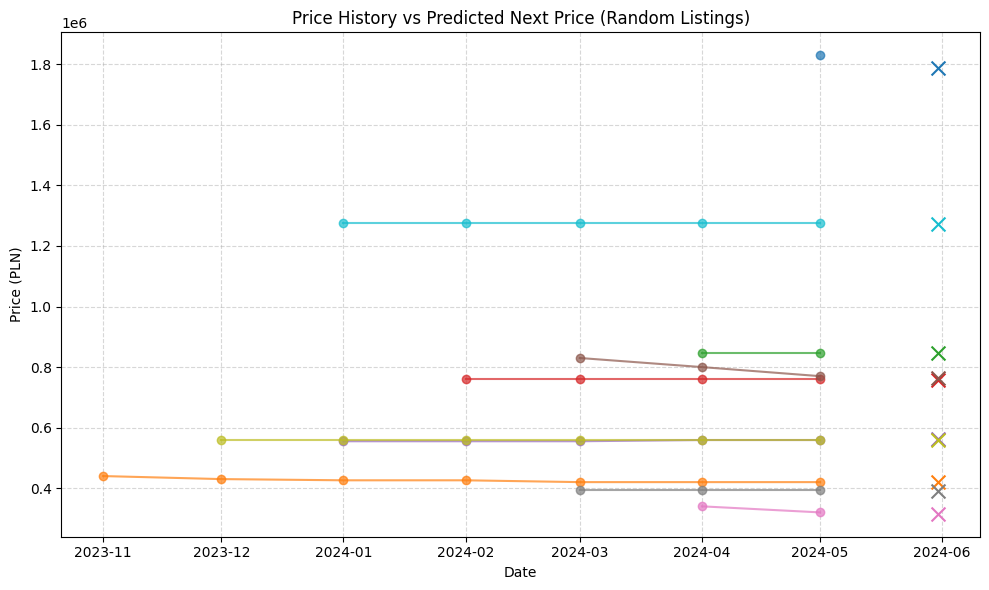

In [71]:
plt.figure(figsize=(10, 6))

for lid in sample_ids:
    s = df[df['listing_id'] == lid].copy()
    s['snapshot_date'] = pd.to_datetime(s['snapshot_date'])
    s = s.sort_values('snapshot_date')

    # plot historical actual prices
    line = plt.plot(s['snapshot_date'], s['price'], 'o-', alpha=0.7, label=f'{lid[:6]} Actual')[0]
    color = line.get_color()

    # predicted next price (use the most recent snapshot)
    if lid in df_valid_eval['listing_id'].values:
        pred_row = df_valid_eval[df_valid_eval['listing_id'] == lid].iloc[-1]
        plt.scatter(
            pred_row['snapshot_date'] + pd.Timedelta(days=30),
            pred_row['predicted_next_price'],
            color=color, marker='x', s=100,
            label=f'{lid[:6]} Predicted', zorder=5
        )

plt.title('Price History vs Predicted Next Price (Random Listings)')
plt.xlabel('Date')
plt.ylabel('Price (PLN)')
# plt.legend(fontsize='small', ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
